## Working with High Resolution Land Cover Data

This Jupyter Notebook is designed to show some how you can work with High Resolution Land Cover Data using the ESA CCI Toolbox. It does so by outlining some steps you might find also useful when working with other datasets.

We start by looking into which Land Cover datasets are available.

In [1]:
from esa_climate_toolbox.core import list_ecv_datasets

list_ecv_datasets("LC")

[('esacci.LC.13-yrs.L4.WB.ASAR.Envisat.Map.4-0.r1', 'esa-cci'),
 ('esacci.LC.yr.L4.LCCS.multi-sensor.multi-platform.Map.2-0-7.r1', 'esa-cci'),
 ('esacci.LC.yr.L4.PFT.Unspecified.Unspecified.Map.2-0-81.r1', 'esa-cci'),
 ('esacci.LC.yr.L4.Map.multi-sensor.multi-platform.HRLC10-A03.v1-2.Siberia',
  'esa-cci'),
 ('esacci.LC.yr.L4.Map.multi-sensor.multi-platform.HRLC10-A02.v1-2.Amazonia',
  'esa-cci'),
 ('esacci.LC.yr.L4.Map.multi-sensor.multi-platform.HRLC10-A01.v1-2.Africa',
  'esa-cci'),
 ('esacci.LC.5-yrs.L4.Map.multi-sensor.multi-platform.HRLC30-A03.v1-2.Siberia',
  'esa-cci'),
 ('esacci.LC.5-yrs.L4.Map.multi-sensor.multi-platform.HRLC30-A02.v1-2.Amazonia',
  'esa-cci'),
 ('esacci.LC.5-yrs.L4.Map.multi-sensor.multi-platform.HRLC30-A01.v1-2.Africa',
  'esa-cci'),
 ('esacci.LC.5-yrs.L4.CHANGE.multi-sensor.multi-platform.HRLCC30-A03.v1-2.Siberia',
  'esa-cci'),
 ('esacci.LC.5-yrs.L4.CHANGE.multi-sensor.multi-platform.HRLCC30-A02.v1-2.Amazonia',
  'esa-cci'),
 ('esacci.LC.5-yrs.L4.CHANGE.m

There are some that carry HRLC in their name. These datasets provide a particularly high resolution of 10-30 metres (for details, see https://climate.esa.int/de/projekte/high-resolution-land-cover/). Those datasets are the ones we want to have a closer look at. You see there arte High Resolution Land Cover Maps at 10m (HRLC10) and at 30m (HRLC30), as well as Land Cover Changes Maps at 30m (HRLCC30). For this notebook, we pick one of the maps at 30m.

In [2]:
hrlc_dataset_name = "esacci.LC.5-yrs.L4.Map.multi-sensor.multi-platform.HRLC30-A02.v1-2.Amazonia"

To open it, we use the xcube store framework to open the `esa-cci` store. We can then display the parameters for opening the data. In many cases, this is not necessary, here it makes sense, as it allows us to see which places are available for this dataset.

In [3]:
from xcube.core.store import new_data_store

cci_store = new_data_store('esa-cci')
cci_store.get_open_data_params_schema(hrlc_dataset_name)

The result of this call is a dictionary which you can extend. If you look at `root->properties-> place_names->items->enum` you get a long list of place names. These place names can be used to specify the regions one is interested in. This helps with managing this dataset, which otherwise would be very huge and hard to handle. You will see the names of many tiles. The tiling is based on the Sentinel-2 Tiling Grid, which you may download here: https://sentiwiki.copernicus.eu/web/s2-products . Each tile covers 100x100 km. For this notebook, we pick tile "A02T20KQA".

In [4]:
places = ["A02T20KQA"]

Using the grid file linked above, we can see that the tile is located in the Gran Chaco region, Paraguay.

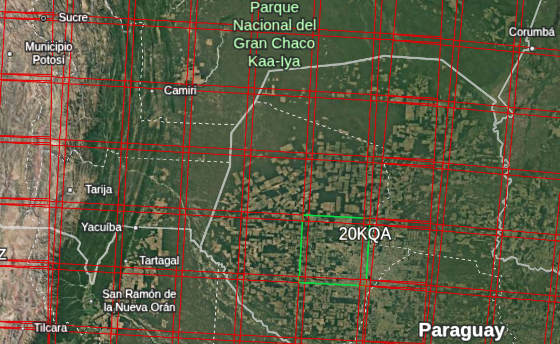

In [5]:
from IPython import display
display.Image("Location_T20KQA.png")

We are now set to actually open the data. For this dataset, it is important to pass the place name using the place_names parameter.
The result is a DataTree object. A DataTree is basically a collection of datasets, indexed by an identifier. In our case, the collection consists of a single dataset, which may be accessed through the place name.

In [6]:
hrlc_dt = cci_store.open_data(
    hrlc_dataset_name,
    place_names=places
)
hrlc_dt

<xarray.DataTree 'esacci.LC.5-yrs.L4.Map.multi-sensor.multi-platform.HRLC30-A02.v1-2.Amazonia'>
Group: /
└── Group: /
        Dimensions:    (time: 7, x: 3660, y: 3660, bnds: 2)
        Coordinates:
          * time       (time) datetime64[ns] 56B 1990-01-01 1995-01-01 ... 2019-01-01
          * x          (x) float64 29kB 7e+05 7e+05 7e+05 ... 8.097e+05 8.097e+05
          * y          (y) float64 29kB 7.6e+06 7.6e+06 7.6e+06 ... 7.49e+06 7.49e+06
            time_bnds  (time, bnds) datetime64[ns] 112B dask.array<chunksize=(7, 2), meta=np.ndarray>
        Dimensions without coordinates: bnds
        Data variables:
            CL01       (time, y, x) uint8 94MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
            CL02       (time, y, x) uint8 94MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
            IQIX       (time, y, x) float32 375MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
            PS01       (time, y, x) uint8 94MB dask.array<chunksize

We can make sure the place is included in the list of keys of the DataTree ...

In [7]:
list(hrlc_dt.keys())

['A02T20KQA']

Perfect. Now we may retrieve the region-specific dataset from the data tree.

In [8]:
hrlc_ds = hrlc_dt.get(places[0]).to_dataset()
hrlc_ds

<xarray.Dataset> Size: 750MB
Dimensions:    (time: 7, y: 3660, x: 3660, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 56B 1990-01-01 1995-01-01 ... 2019-01-01
  * x          (x) float64 29kB 7e+05 7e+05 7e+05 ... 8.097e+05 8.097e+05
  * y          (y) float64 29kB 7.6e+06 7.6e+06 7.6e+06 ... 7.49e+06 7.49e+06
    time_bnds  (time, bnds) datetime64[ns] 112B dask.array<chunksize=(7, 2), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    CL01       (time, y, x) uint8 94MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    CL02       (time, y, x) uint8 94MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    IQIX       (time, y, x) float32 375MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    PS01       (time, y, x) uint8 94MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    PS02       (time, y, x) uint8 94MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    title:                   esacci.LC.5-yrs.L4.Map.multi-sensor.multi-platfo...
    date_created:            2026-02-27T14:25:48.759507
    processing_level:        L4
    time_coverage_start:     1990-01-01T00:00:00
    time_coverage_end:       2019-01-01T00:00:00
    time_coverage_duration:  P10592DT0H0M0S
    history:                 [{'program': 'xcube_cci.chunkstore.CciChunkStore...

One thing to notice here is that we do not have latitude/longitude coordinates. This is because the data is provided in a UTM projection. We can work with this just fine, but some may prfer to work in WGS 84, so we show how to reproject to that. It basically follows the approach outlined in the `Reprojecting_Data` notebook in the `Using_Operations` section. We start by determining the grid mapping of the dataset.
You can also find more information on any operation in the [Documentation of the Toolbox](https://esa-climate-toolbox.readthedocs.io/en/latest/api_reference.html#operations).

In [9]:
from xcube.core.gridmapping import GridMapping

source_gm = GridMapping.from_dataset(hrlc_ds)
source_gm

class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: _unknown_
* crs: PROJCS["WGS 84 / UTM zone 20S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-63],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32720"]]
* xy_res: (30, 30)
* xy_bbox: (699960, 7490220, 809760, 7600020)
* ij_bbox: (0, 0, 3660, 3660)
* xy_dim_names: ('x', 'y')
* xy_var_names: ('x', 'y')
* size: (3660, 3660)
* tile_size: (1830, 1830)

As expected, it is a UTM projection. The safest way to get the target grid mapping is to transform the source to the desired crs.

In [10]:
target_gm = source_gm.transform("EPSG:4326")
target_gm

class: **Coords2DGridMapping**
* is_regular: dask.array<all-aggregate, shape=(), dtype=bool, chunksize=(), chunktype=numpy.ndarray>
* is_j_axis_up: dask.array<all-aggregate, shape=(), dtype=bool, chunksize=(), chunktype=numpy.ndarray>
* is_lon_360: False
* crs: EPSG:4326
* xy_res: (0.00028985122477109826, 0.00027089213894981867)
* xy_bbox: (-61.06720759071305, -22.683370470251425, -59.985744284394286, -21.676220921562614)
* ij_bbox: (0, 0, 3660, 3660)
* xy_dim_names: ('x', 'y')
* xy_var_names: ('transformed_x', 'transformed_y')
* size: (3660, 3660)
* tile_size: (1830, 1830)

As we now have the target grid mapping defined, we can now reproject the dataset.

In [11]:
from xcube.core.resampling import resample_in_space

hrlc_ds = resample_in_space(
    hrlc_ds,
    source_gm=source_gm,
    target_gm=target_gm,
)
hrlc_ds

<xarray.Dataset> Size: 750MB
Dimensions:        (time: 7, y: 3660, x: 3660, bnds: 2)
Coordinates:
  * time           (time) datetime64[ns] 56B 1990-01-01 ... 2019-01-01
    time_bnds      (time, bnds) datetime64[ns] 112B dask.array<chunksize=(7, 2), meta=np.ndarray>
    spatial_ref    int64 8B 0
    transformed_x  (x) float64 29kB -61.07 -61.07 -61.07 ... -59.99 -59.99
    transformed_y  (y) float64 29kB -21.68 -21.68 -21.68 ... -22.68 -22.68
Dimensions without coordinates: y, x, bnds
Data variables:
    CL01           (time, y, x) uint8 94MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    CL02           (time, y, x) uint8 94MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    IQIX           (time, y, x) float32 375MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    PS01           (time, y, x) uint8 94MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    PS02           (time, y, x) uint8 94MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    crs            int64 8B 0
Attributes:
    Conventions:             CF-1.7
    title:                   esacci.LC.5-yrs.L4.Map.multi-sensor.multi-platfo...
    date_created:            2026-02-27T14:25:48.759507
    processing_level:        L4
    time_coverage_start:     1990-01-01T00:00:00
    time_coverage_end:       2019-01-01T00:00:00
    time_coverage_duration:  P10592DT0H0M0S
    history:                 [{'program': 'xcube_cci.chunkstore.CciChunkStore...

The reprojection was successful. We finish by renaming the coordinates and dimensions.

In [12]:
hrlc_ds = hrlc_ds.rename({"x": "lon", "y": "lat", "transformed_x": "lon", "transformed_y": "lat"})
hrlc_ds

<xarray.Dataset> Size: 750MB
Dimensions:      (time: 7, lat: 3660, lon: 3660, bnds: 2)
Coordinates:
  * time         (time) datetime64[ns] 56B 1990-01-01 1995-01-01 ... 2019-01-01
    time_bnds    (time, bnds) datetime64[ns] 112B dask.array<chunksize=(7, 2), meta=np.ndarray>
    spatial_ref  int64 8B 0
    lon          (lon) float64 29kB -61.07 -61.07 -61.07 ... -59.99 -59.99
    lat          (lat) float64 29kB -21.68 -21.68 -21.68 ... -22.68 -22.68
Dimensions without coordinates: bnds
Data variables:
    CL01         (time, lat, lon) uint8 94MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    CL02         (time, lat, lon) uint8 94MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    IQIX         (time, lat, lon) float32 375MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    PS01         (time, lat, lon) uint8 94MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    PS02         (time, lat, lon) uint8 94MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    crs          int64 8B 0
Attributes:
    Conventions:             CF-1.7
    title:                   esacci.LC.5-yrs.L4.Map.multi-sensor.multi-platfo...
    date_created:            2026-02-27T14:25:48.759507
    processing_level:        L4
    time_coverage_start:     1990-01-01T00:00:00
    time_coverage_end:       2019-01-01T00:00:00
    time_coverage_duration:  P10592DT0H0M0S
    history:                 [{'program': 'xcube_cci.chunkstore.CciChunkStore...

Now let's have a look at how best to plot the data. Say we want to have a look at the main land cover class which is provided in "CL01". This might be a little tricky as this is categorical data, but most color plots are designed to plot continuous data. To plot categorical data, we can use the toolbox' `plot_categorical` operation.

In [13]:
from esa_climate_toolbox.core import get_op

plot_categorical = get_op("plot_categorical")

To make sure the plots are shown directly in the notebook, the following line must be executed.

In [14]:
%matplotlib inline

We may now use the operation. You may pass to this operation 
 - a list of color indices
 - a list of colors in string format (e.g., #00FFAA)
 - a list of labels

However, there are also predefined color maps, for example the one for displaying high resolution land cover data. We use this one. To indicate which time slice we want to pick, we use the indexers function. Also, in the properties part, we pass the matplotlib keyword argument `figsize` to adjust the size.

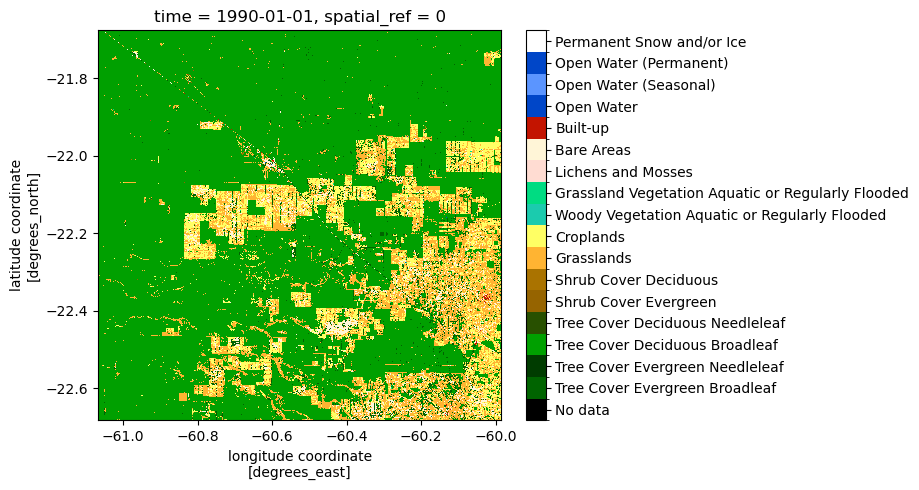

In [15]:
plot_categorical(hrlc_ds, "CL01", indexers={"time": hrlc_ds.time[0].values}, color_scheme_name="highres_land_cover_cci", properties=dict(figsize=(9, 5)))

To create one plot per time step, it makes sense to create a wrapper function that extracts the time. We may also use this to create a well-readable title.

In [16]:
import pandas as pd

def plot_hrlc(timestep: int):
    time = hrlc_ds.time[timestep].values
    year = pd.Timestamp(time).strftime("%Y")
    title = f"High Resolution Land Cover in the Gran Chaco Region, Paraguay - {year}"

    plot_categorical(
        hrlc_ds, 
        "CL01", 
        indexers={"time": time}, 
        title=title, 
        color_scheme_name="highres_land_cover_cci", 
        properties=dict(figsize=(9, 5))
    )

Now that we have the method defined, we can use it for each of the seven time steps:

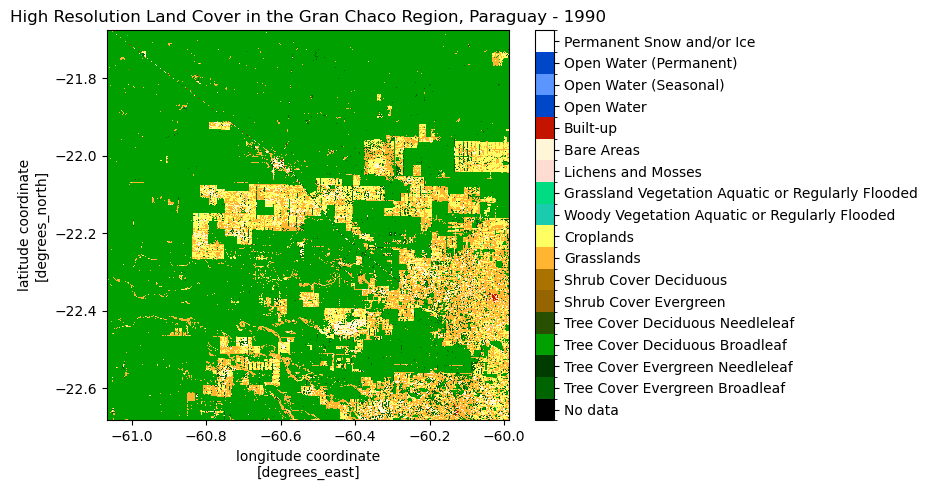

In [17]:
plot_hrlc(0)

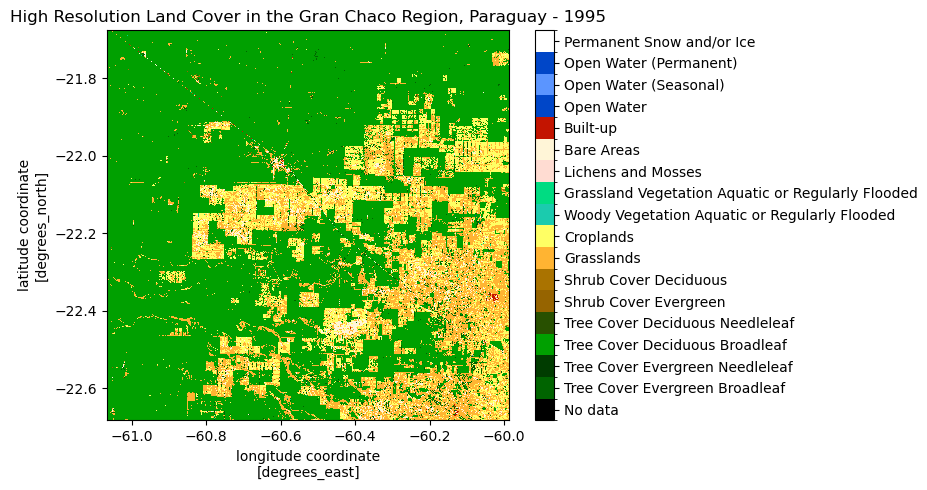

In [18]:
plot_hrlc(1)

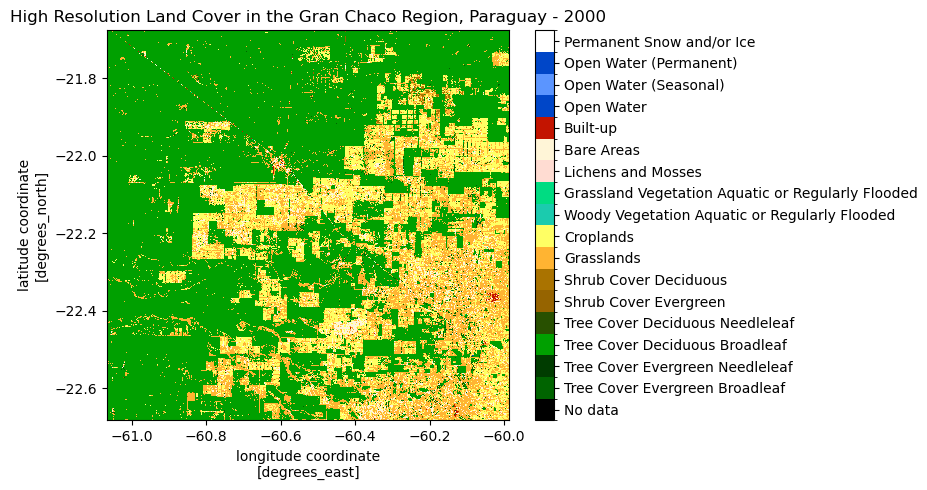

In [19]:
plot_hrlc(2)

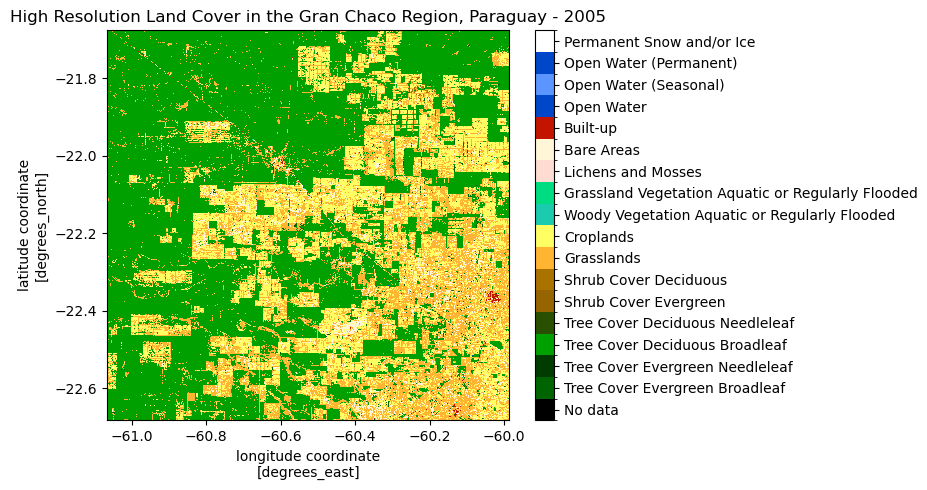

In [20]:
plot_hrlc(3)

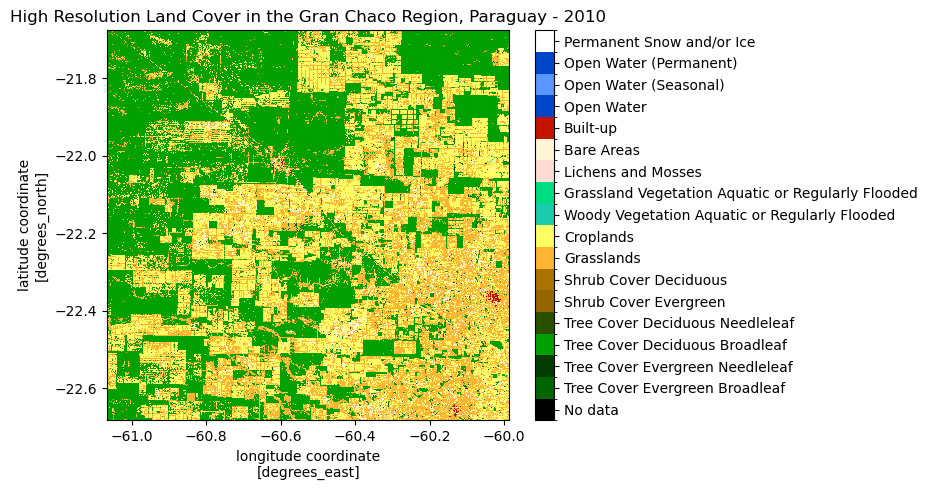

In [21]:
plot_hrlc(4)

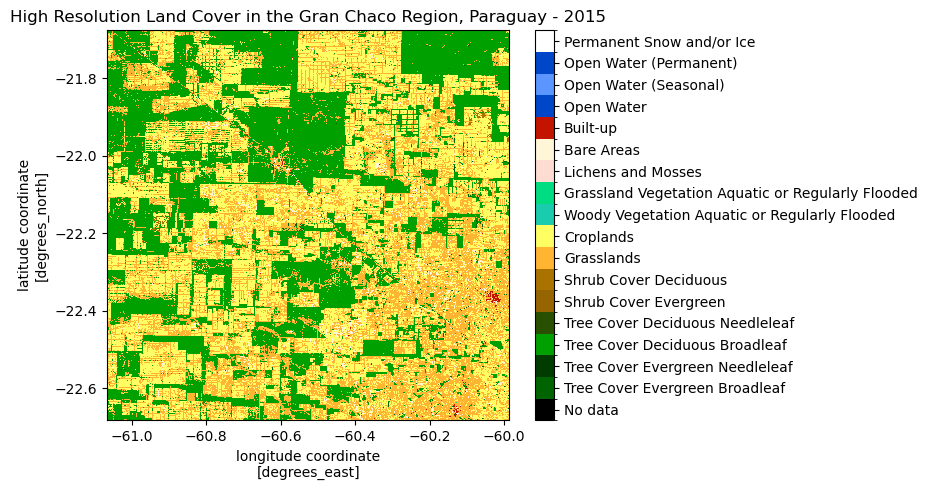

In [22]:
plot_hrlc(5)

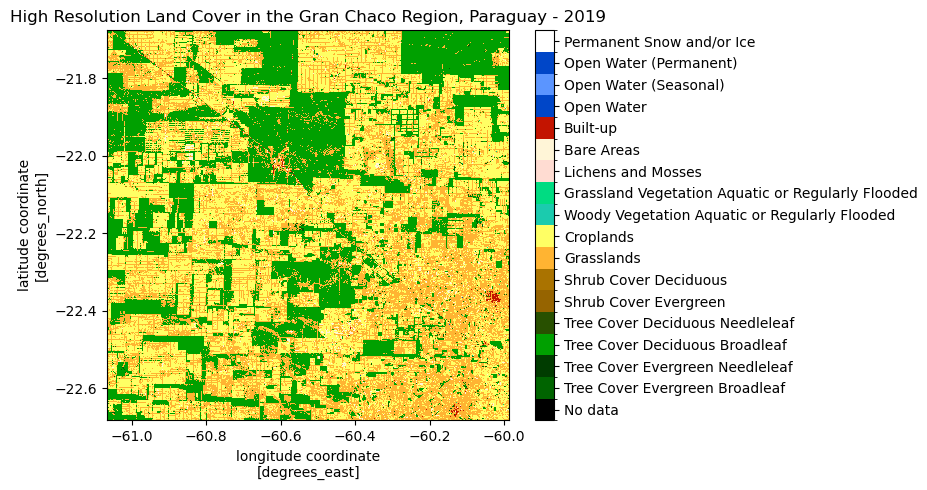

In [23]:
plot_hrlc(6)